In [3]:
import main as m
import pandas as pd

In [4]:
db_path = 'human_genome.db'

germline_raw = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet')
somatic_raw = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet')
res = pd.concat([germline_raw, somatic_raw], ignore_index=True)
res['Gene'] = res['Gene'].astype(str).str.strip()


sample_id = 'random_id'

In [11]:
outrider = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet')
protein = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet')

In [13]:
over = outrider[outrider['zScore'] > 0]
under = outrider[outrider['zScore'] < 0]

# just look at predisposition genes
over_predisp = over[over['padjust_predisp_extended'].notna()]
under_predisp = under[under['padjust_predisp_extended'].notna()]

In [18]:
over_predisp.head()

,geneID,PROTEIN_LOG2INT,PROTEIN_EXPECTED_LOG2INT,PROTEIN_INT,zScore,pValue,padjust,PROTEIN_LOG2FC,PROTEIN_FC,aberrant,pvalDistribution,geneID_short,Gene,IMPACT_snv,Consequence_snv,ANNOTATION_control_snv,promoterAI_snv,Location_snv,Allele_snv,ref_snv,#Uploaded_variation_snv,IMPACT_indel,Consequence_indel,ANNOTATION_control_indel,Location_indel,Allele_indel,variant_type,IMPACT,Outlier status,padjust_predisp,padjust_predisp_extended,CNV,Diag,seq_type,Oncotree Code,random_id
155,ENSG00000002822.11,9.726901,1180.914012,3037,3.949849,0.000005,0.098702,-inf,0.000000e+00,True,nb,ENSG00000002822,None,MODIFIER,intron_variant,germline,NaN,7:1949703,G,C,7_1949703_C/G,MODIFIER,intron_variant,germline,7:1888725-1888726,ACACATGCACACACACATACACGTGC,"snv,indel",MODIFIER,Non-outlier,NaN,0.002838,Somatic_AMP,Biliary_Tract,WGS,GBAD,DXF2679
156,ENSG00000002822.11,8.852661,4062.002776,10380,3.925499,0.000005,0.539198,-inf,0.000000e+00,False,nb,ENSG00000002822,None,MODIFIER,intron_variant,germline,NaN,7:1885312,G,C,7_1885312_C/G,MODIFIER,intron_variant,germline,7:1910464,-,"snv,indel",MODIFIER,Non-outlier,NaN,0.003071,Somatic_DUP,Bone,WGS,CHS,FGA2480
157,ENSG00000002822.11,8.103760,733.692046,1662,3.434702,0.000114,0.394774,-inf,0.000000e+00,False,nb,ENSG00000002822,None,MODERATE,missense_variant,germline,NaN,7:1976401,T,C,rs200811813,MODIFIER,intron_variant,germline,7:1888725-1888726,ACACATGCACACACACATACACGTGC,"snv,indel",MODERATE,Non-outlier,NaN,0.034644,No CNV,Bone,WGS,EMCHS,VBS0656
158,ENSG00000002822.11,7.192801,356.751556,815,3.465693,0.000110,0.440439,-504.306671,1.543707e-152,False,nb,ENSG00000002822,None,None,None,None,NaN,None,None,None,None,MODIFIER,intron_variant,germline,7:2212102-2212103,G,indel,MODIFIER,Non-outlier,NaN,0.033617,No CNV,COAD,WES,COAD,VYX4855
160,ENSG00000002822.11,8.762629,1027.737155,2446,3.635691,0.000035,0.161620,-inf,0.000000e+00,False,nb,ENSG00000002822,None,MODIFIER,upstream_gene_variant,germline,-0.1946,7:1980569,T,C,rs58869359,MODIFIER,intron_variant,germline,7:1910464,-,"snv,indel",MODIFIER,Non-outlier,NaN,0.014122,No CNV,Other,WGS,CAPNEC,HHM2075


In [21]:
top_n = 10
all_pathways = m.get_top_pathways(outrider, db_path, n=top_n)
over_pathways = m.get_top_pathways(over, db_path, n=top_n)
under_pathways = m.get_top_pathways(over, db_path, n=top_n)
over_predisp_pathways = m.get_top_pathways(over_predisp, db_path, n=top_n)
under_predisp_pathways = m.get_top_pathways(under_predisp, db_path, n=top_n)

In [22]:
pathway_data_dict = {
    'All Expression Outliers': all_pathways,
    'Overexpression (z Score > 0)': over_pathways,
    'Underexpression (z Score < 0)': under_pathways,
    'Overexpression only with predisposition genes': over_predisp_pathways,
    'Underexpression only with predisposition genes': under_predisp_pathways
}

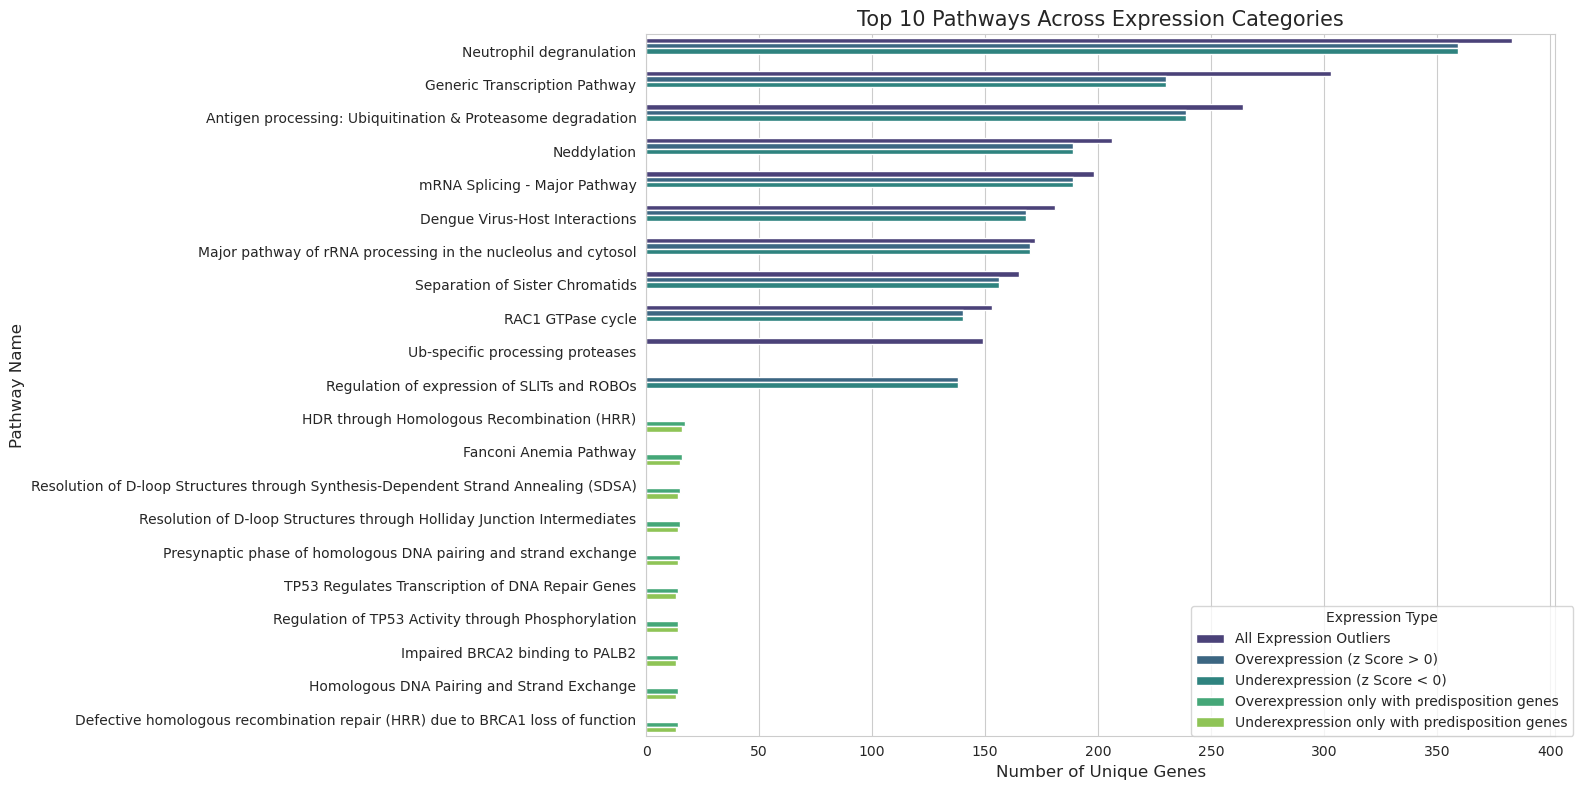

In [24]:
m.plot_pathway_comparison(pathway_data_dict, n=top_n)